In [47]:
"""
# Use to learn and test the data and run the algorithm GRMMF
# --- Import Modules --- #
"""

# --- Import Modules --- #
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from RFMN import ReflexFuzzyNeuroNetwork
import time
import string
import random



In [48]:
# data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\iris_data_norm.csv')
# data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\iris_data_norm - 2 col.csv')
# data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\mydata_norm - 2 column.csv')
data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labels.csv')


data = data.iloc[:,1:]

# print(data)


X = data.iloc[:,:-1] # for every y (class) we get a 4-D array. E.g., I'm in the 5th dimension. 
y = data.iloc[:,-1] # same as saying y coresponds to the respective classes. E.g., w = 1,2 or 3.
print("sksks", type(X))
# print(y)
# print(X.dtypes) 

# X = [[0.4,0.3],[0.6,0.25],[0.7,0.6], [0.9, 0.65], [.5,.29], [.65,.5]]
# # y = [[1],[1],[0],[0],[0], [0]]
# y = {1, 1, 0, 0, 0, 0}
# print(y.shape)

print(X.min)
print(X.max)
print(y)

sksks <class 'pandas.core.frame.DataFrame'>
<bound method NDFrame._add_numeric_operations.<locals>.min of        Displacement  Force    Work
0                 4   0.00    0.00
1                 3   0.00    0.00
2                 0   0.00    0.00
3                 3   0.00    0.00
4                 2   0.00    0.00
...             ...    ...     ...
10795            10  21.40  213.95
10796             9  21.44  192.93
10797             8  21.44  171.50
10798            10  21.44  214.37
10799             9  21.40  192.56

[10800 rows x 3 columns]>
<bound method NDFrame._add_numeric_operations.<locals>.max of        Displacement  Force    Work
0                 4   0.00    0.00
1                 3   0.00    0.00
2                 0   0.00    0.00
3                 3   0.00    0.00
4                 2   0.00    0.00
...             ...    ...     ...
10795            10  21.40  213.95
10796             9  21.44  192.93
10797             8  21.44  171.50
10798            10  21.44  214.37


In [49]:
scaler_min_max = MinMaxScaler(feature_range=(0.001, .99))
X_norm = scaler_min_max.fit_transform(X)

# print(X_norm.shape)
# print(X_norm)


print(X.min)
# My created norm
# X_norm = (X-X.min())/(X.max()-X.min())
# X_norm = X_norm.values
# print(X_norm.shape)
# print(X_norm)



<bound method NDFrame._add_numeric_operations.<locals>.min of        Displacement  Force    Work
0                 4   0.00    0.00
1                 3   0.00    0.00
2                 0   0.00    0.00
3                 3   0.00    0.00
4                 2   0.00    0.00
...             ...    ...     ...
10795            10  21.40  213.95
10796             9  21.44  192.93
10797             8  21.44  171.50
10798            10  21.44  214.37
10799             9  21.40  192.56

[10800 rows x 3 columns]>


In [50]:
# Split the data between train and test. 
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.33, random_state=42) # Split the data to 33% to test, and 66% to training
                                            #These value come in four 66X1 matrices for X_train and X_test
                                            # and one 66X1 matrix for y_train and y_test. 
                                            # random state = 42
print(" This is X_train \n", X_train, "\n" )
print(" This is X_test \n", X_test, "\n" )
print(" This is y_train \n", y_train, "\n" )
print(" This is y_test \n", y_test, "\n" )


# print("X train \n", X_train)
# # print("Y train \n", y_train)
# # print("X train len \n", len(X_train))
# # print("Y train len \n", len(y_train))
# print("X train shape \n", X_train.shape)
# print("Y train shape\n", y_train.shape)


# print("X test 1 \n", X_test)
# # print("Y test 1 \n", y_test)
# # print("X test len \n", len(X_test))
# # print("Y test len \n", len(y_test))
# print("X test shape \n", X_test.shape)
# print("Y test shape\n", y_test.shape)



 This is X_train 
 [[0.116      0.6838749  0.08049236]
 [0.06105556 0.001      0.001     ]
 [0.08661111 0.4526933  0.04014698]
 [0.25016667 0.41687285 0.10588418]
 [0.57472222 0.89600308 0.5207824 ]
 [0.24633333 0.22786283 0.0573534 ]
 [0.55172222 0.39680324 0.22164203]
 [0.1735     0.24793244 0.044125  ]
 [0.01633333 0.57946211 0.00997732]
 [0.00483333 0.001      0.001     ]
 [0.11344444 0.001      0.001     ]
 [0.23738889 0.21007963 0.0510052 ]
 [0.185      0.68184254 0.12779483]
 [0.001      0.55710609 0.001     ]
 [0.11727778 0.001      0.001     ]
 [0.52616667 0.32617853 0.17381117]
 [0.32172222 0.9127701  0.29705121]
 [0.94527778 0.98898382 0.94527768]
 [0.31788889 0.16892422 0.05483042]
 [0.33833333 0.61960134 0.21219382]
 [0.63605556 0.9244562  0.59466853]
 [0.24633333 0.22583046 0.05682896]
 [0.58622222 0.97297894 0.57684368]
 [0.6335     0.92039147 0.58957656]
 [0.00866667 0.78625533 0.00709387]
 [0.22077778 0.13081736 0.02988122]
 [0.07511111 0.001      0.001     ]
 [0.12877

In [51]:
y_train, y_test = y_train.values, y_test.values # Transpose the y_train and y_test data. 
                                # Essentailly we go from a 66X1 matrices to a 1x66 matrices. 
X_train, X_test = X_train.T, X_test.T # Transpose the X_train and X_test data. 
                                # Essentailly we go from four 66X1 matrices to four 1x66 matrices. 
# print(" This is X_train.T \n", X_train, "\n" )
# print(" This is X_test.T \n", X_test, "\n" )
# print(" This is y_train.values \n", y_train, "\n" )
# print(" This is y_test.values \n", y_test, "\n" )



print("X train \n", X_train)
print("Y train \n", y_train)
# print("X train len \n", len(X_train))
# print("Y train len \n", len(y_train))
print("X train shape \n", X_train.shape)
print("Y train shape\n", y_train.shape)


print("X test 1 \n", X_test)
print("Y test 1 \n", y_test)
# # # print("X test len \n", len(X_test))
# print("Y test len \n", len(y_test))
print("X test shape \n", X_test.shape)
print("Y test shape\n", y_test.shape)

X train 
 [[0.116      0.06105556 0.08661111 0.25016667 0.57472222 0.24633333
  0.55172222 0.1735     0.01633333 0.00483333 0.11344444 0.23738889
  0.185      0.001      0.11727778 0.52616667 0.32172222 0.94527778
  0.31788889 0.33833333 0.63605556 0.24633333 0.58622222 0.6335
  0.00866667 0.22077778 0.07511111 0.12877778 0.15561111 0.5185
  0.03038889 0.22205556 0.37027778 0.21694444 0.11344444 0.50572222
  0.23738889 0.00355556 0.37155556 0.36772222 0.3115     0.07
  0.08022222 0.08022222 0.07127778 0.3345     0.12111111 0.18627778
  0.277      0.38816667 0.01505556 0.50827778 0.38944444 0.22844444
  0.22716667 0.26294444 0.01633333 0.277      0.48655556 0.65011111
  0.24505556 0.37538889 0.277      0.30255556 0.04061111 0.18755556
  0.21055556 0.03933333 0.29488889 0.20544444 0.24377778 0.09811111
  0.11727778 0.0125     0.03677778 0.36261111 0.06872222 0.0815
  0.59644444 0.35494444 0.67438889 0.32427778 0.19011111 0.16711111
  0.39072222 0.07255556 0.09555556 0.08405556 0.20033333

In [52]:

# # # --- Declare network --- "
nn = ReflexFuzzyNeuroNetwork(gamma=1, theta=.1)
# '''
# X_trian after the X_train.T (transponse) is an "array [[column 1,column 2, column 3, column 4"]]
# y_train after the y_train.values (transpose) is an array[column 5]
# '''
# --- Train network --- #
nn.train(X_train, y_train)

In [53]:
# import sys
# import numpy
# numpy.set_printoptions(threshold=sys.maxsize)

# --- Test Network --- #
y_predlr = nn.test(X_test,y_test)
# print(nn.query([0.22,0.62,.067,0.04]))

print(y_predlr)
print(type(y_predlr))


print(y_test)
print(type(y_test))



[6 8 2 9 8 4 3 5 4 1 4 9 7 4 9 5 3 7 4 4 5 4 2 9 1 6 4 4 1 9 7 4 4 5 9 9 9
 5 1 3 9 2 9 9 1 1 7 2 2 4 2 8 8 5 7 4 9 8 6 8 2 1 1 6 7 4 3 4 5 5 2 4 8 6
 9 5 5 7 1 4 9 2 5 5 2 9 6 9 9 4 6 7 5 5 8 8 4 9 2 8 5 9 9 6 8 2 7 5 4 5 4
 6 1 3 9 6 5 1 9 9 5 3 3 4 5 7 4 4 9 3 5 3 9 7 4 2 3 7 3 5 9 9 6 9 7 8 2 2
 2 3 9 2 1 5 2 3 3 4 8 7 6 3 5 9 1 9 4 6 3 1 9 1 7 8 9 3 7 1 1 1 8 3 1 3 1
 1 5 8 5 8 4 2 9 4 3 2 6 8 6 8 5 6 9 9 7 3 3 7 2 1 1 4 1 7 5 3 1 2 9 5 8 6
 3 4 7 5 9 2 5 1 2 9 3 4 1 7 9 1 7 3 1 7 7 3 9 6 5 8 3 9 9 3 6 7 2 4 7 9 1
 8 1 7 4 3 8 4 8 3 5 3 8 2 5 8 1 9 1 4 3 7 4 9 2 1 6 3 5 2 6 8 1 7 4 7 6 2
 2 9 7 7 4 8 8 2 1 4 6 8 4 8 2 6 3 8 1 2 3 2 1 4 9 2 7 6 8 5 4 4 5 3 8 6 9
 8 4 8 2 2 2 1 6 5 8 7 5 5 8 6 8 4 9 6 6 2 1 6 2 3 9 1 5 7 3 1 4 6 3 7 3 8
 3 5 5 7 5 6 1 4 2 9 1 8 2 1 3 5 9 2 1 5 7 7 7 1 4 4 6 1 2 4 5 7 8 9 6 6 5
 6 3 6 7 2 8 2 7 3 2 7 7 5 1 7 2 5 8 4 5 9 8 8 2 2 3 9 8 9 9 9 1 5 4 1 4 4
 9 8 9 8 7 1 8 7 6 8 1 1 5 1 4 6 1 7 1 4 5 3 9 7 6 7 9 1 9 6 1 2 7 8 6 9 1
 6 5 9 9 4 7 9 5 4 5 2 8 

In [54]:
from sklearn.metrics import confusion_matrix

import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)

print(y_predlr)
print(type(y_predlr))
print(len(y_predlr))

print(y_test)
print(type(y_test))
print(len(y_test))





[6 8 2 9 8 4 3 5 4 1 4 9 7 4 9 5 3 7 4 4 5 4 2 9 1 6 4 4 1 9 7 4 4 5 9 9 9
 5 1 3 9 2 9 9 1 1 7 2 2 4 2 8 8 5 7 4 9 8 6 8 2 1 1 6 7 4 3 4 5 5 2 4 8 6
 9 5 5 7 1 4 9 2 5 5 2 9 6 9 9 4 6 7 5 5 8 8 4 9 2 8 5 9 9 6 8 2 7 5 4 5 4
 6 1 3 9 6 5 1 9 9 5 3 3 4 5 7 4 4 9 3 5 3 9 7 4 2 3 7 3 5 9 9 6 9 7 8 2 2
 2 3 9 2 1 5 2 3 3 4 8 7 6 3 5 9 1 9 4 6 3 1 9 1 7 8 9 3 7 1 1 1 8 3 1 3 1
 1 5 8 5 8 4 2 9 4 3 2 6 8 6 8 5 6 9 9 7 3 3 7 2 1 1 4 1 7 5 3 1 2 9 5 8 6
 3 4 7 5 9 2 5 1 2 9 3 4 1 7 9 1 7 3 1 7 7 3 9 6 5 8 3 9 9 3 6 7 2 4 7 9 1
 8 1 7 4 3 8 4 8 3 5 3 8 2 5 8 1 9 1 4 3 7 4 9 2 1 6 3 5 2 6 8 1 7 4 7 6 2
 2 9 7 7 4 8 8 2 1 4 6 8 4 8 2 6 3 8 1 2 3 2 1 4 9 2 7 6 8 5 4 4 5 3 8 6 9
 8 4 8 2 2 2 1 6 5 8 7 5 5 8 6 8 4 9 6 6 2 1 6 2 3 9 1 5 7 3 1 4 6 3 7 3 8
 3 5 5 7 5 6 1 4 2 9 1 8 2 1 3 5 9 2 1 5 7 7 7 1 4 4 6 1 2 4 5 7 8 9 6 6 5
 6 3 6 7 2 8 2 7 3 2 7 7 5 1 7 2 5 8 4 5 9 8 8 2 2 3 9 8 9 9 9 1 5 4 1 4 4
 9 8 9 8 7 1 8 7 6 8 1 1 5 1 4 6 1 7 1 4 5 3 9 7 6 7 9 1 9 6 1 2 7 8 6 9 1
 6 5 9 9 4 7 9 5 4 5 2 8 

In [55]:

# y_test2 = np.array_str(y_test)

# # print(np.fromstring(y_test2, dtype=str))
# # print(y_test)
# # print(type(y_test2))

# print(len(y_predlr))


# print(len(y_test))

confusion_matrix(y_test, y_predlr)



array([[405,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 266,  29,  64,  19,  14,   2,   1,  13],
       [  0,  58, 274,  35,   2,   7,   2,   0,   1],
       [  0,  31,  39, 262,  48,   8,  10,   0,   4],
       [  0,  35,  19,  57, 243,  26,   2,   6,   8],
       [  0,  17,  17,  12,  12, 262,  49,  15,   8],
       [ 21,   0,   3,  20,   0,  17, 306,  13,   4],
       [  0,   1,  12,  10,  19,  42,   8, 315,   0],
       [  0,  15,   5,   0,  28,   0,   0,   4, 339]], dtype=int64)

In [56]:
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef

# unique_labels(y_train)
unique_labels(y_test)

array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [57]:
def plot(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return table


plot(y_test, y_predlr)

,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5,Predicted 6,Predicted 7,Predicted 8,Predicted 9
Actual 1,405,0,0,0,0,0,0,0,0
Actual 2,0,266,29,64,19,14,2,1,13
Actual 3,0,58,274,35,2,7,2,0,1
Actual 4,0,31,39,262,48,8,10,0,4
Actual 5,0,35,19,57,243,26,2,6,8
Actual 6,0,17,17,12,12,262,49,15,8
Actual 7,21,0,3,20,0,17,306,13,4
Actual 8,0,1,12,10,19,42,8,315,0
Actual 9,0,15,5,0,28,0,0,4,339


0.7497194163860831


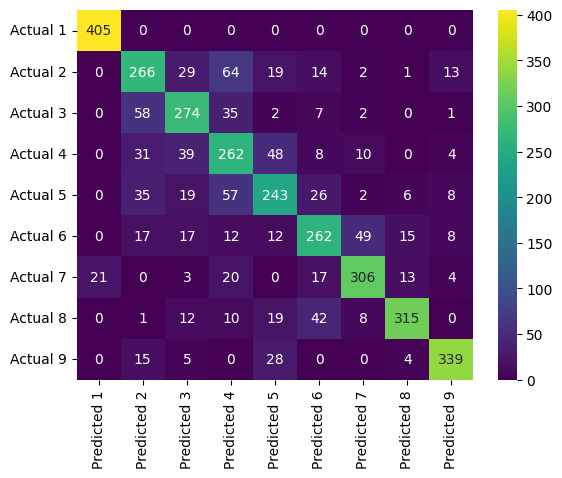

In [64]:
import seaborn as sns

def plot2(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')

plot2(y_test, y_predlr)

accuracy_score1 = accuracy_score(y_test, y_predlr)
print(accuracy_score1)


In [59]:

# accuracy_score = accuracy_score(y_test, y_predlr)
# print(accuracy_score)

# precision_score = precision_score(y_test, y_predlr)

# f1_score = f1_score(y_test, y_predlr)
# print(f1_score)

# fbeta_score = fbeta_score(y_test, y_predlr, beta=0.5)
# print("beta = 0.5", fbeta_score)

# fbeta_score(y_test, y_predlr, beta=2)
# print("beta = 2", fbeta_score)

# matthews_corrcoef = matthews_corrcoef(y_test, y_predlr)
# print(matthews_corrcoef)

In [60]:
# %matplotlib ipympl


# import time
# import serial
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import numpy as np

# def animate(i, dataList, ser):
      

#         ser.write(b'g')                                     # Transmit the char 'g' to receive the Arduino data point
#         arduinoData_string = ser.readline().decode('ascii') # Decode receive Arduino data as a formatted string
#         a = list(map(str.strip, arduinoData_string.split(',')))
       
#         #print(i)                                           # 'i' is a incrementing variable based upon frames = x argument

#         # print(type(arduinoData_string))

#         try:
#                 # arduinoData_float = float(arduinoData_string)   # Convert to float
#                 # print("This is Arduino Data ", arduinoData_float)
#                 # print("This is Arduino Data type ", type(arduinoData_float), "\n")

#                 # dataList.append(arduinoData_float)
#                 # print("This is dataList", dataList)
#                 # print("This is dataList type ", type(dataList), "\n")

#                 b = [float(i) for i in a]
#                 print(b)
#                 print(type(b))  
#                 c = b[0]+ b[1]+ b[2]
#                 print(c)
#                 print(type(c))
#                 dataList.append(c)
                
#                 # b = [float(i) for i in a]
#                 # norm_ful = (b-X.min())/(X.max()-X.min())
#                 # norm_ful = norm_ful.values
#                 # print(norm_ful)
#                 # prediction = nn.predict(norm_ful)
#                 # print(prediction)
#                 # dataList.append(prediction)              # Add to the list holding the fixed number of points to animate
              
#         except:                                             # Pass if data point is bad                               
#                 pass    

#         dataList = dataList[-50:]                           # Fix the list size so that the animation plot 'window' is x number of points

#         ax.clear()                                          # Clear last data frame
#         ax.plot(dataList)                                   # Plot new data frame

#         ax.set_ylim([0, 1200])                              # Set Y axis limit of plot
#         ax.set_title("Arduino Data")                        # Set title of figure
#         ax.set_ylabel("Value")                              # Set title of y axis 

# dataList = []                                           # Create empty list variable for later use
                                                        
# fig = plt.figure()                                      # Create Matplotlib plots fig is the 'higher level' plot window
# ax = fig.add_subplot(111)                               # Add subplot to main fig window

# ser = serial.Serial("COM10", 9600)                       # Establish Serial object with COM port and BAUD rate to match Arduino Port/rate
# print(ser)

# time.sleep(2)                                           # Time delay for Arduino Serial initialization 

#                                                         # Matplotlib Animation Fuction that takes takes care of real time plot.
#                                                         # Note that 'fargs' parameter is where we pass in our dataList and Serial object. 
# ani = animation.FuncAnimation(fig, animate, frames=100, fargs=(dataList, ser), interval=50) 

# plt.show()                                              # Keep Matplotlib plot persistent on screen until it is closed
# ser.close()                                             # Close Serial connection when plot is closed

    

In [61]:
# %matplotlib notebook

# import random
# import numpy as np
# import pandas as pd
# from itertools import count
# from datetime import datetime
# import time
# from matplotlib.animation import FuncAnimation
# from matplotlib.figure import Figure
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches


# # cinstants and x array
# label = []
# x_label = []
# pred_x = 0

# fig = Figure(figsize = (5,5), dpi = 100)
# fig.suptitle('I-V Curve')
# ax = fig.add_subplot(111)
# ax.set_xlabel('Voltage (V)')
# ax.set_ylabel('Current (A)')
# ax.grid(color = "green", linestyle = '--', linewidth = 0.5)



# def animate(i):
#         ful = []
#         global pred_x
#         data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_live.csv')

#         # x = data['x_value']
#         y1 = data['Displacement']
#         y2 = data['Force']
#         y3 = data['Work']


#         len1 = y1.size
#         len2 = y2.size
#         len3 = y3.size



#         ful.append(y1[len1-1])
#         ful.append(y2[len2-1])
#         ful.append(y3[len3-1])






#         norm_ful = (ful-X.min())/(X.max()-X.min())
#         norm_ful = norm_ful.values



# #         prediction = nn.predict(norm_df)

# #         # print(df)
# #         # print(X)
# #         # print(X.min())
# #         # print(X.max())
# #         print(norm_df)

# #         print(prediction)

        
#         prediction = nn.predict(norm_ful)
        

#         label.append(prediction)
#         x_label.append(pred_x)
      

#         pred_x = pred_x + 1

#         data_y = pd.Series(label)

#         data_x = pd.Series(x_label)

#         plt.cla()
#         plt.plot(data_x, data_y, label='Channel 1')
#         plt.xlim(i-30, i+10)
#         plt.ylim(y[i]-5, y[i]+5)
#         plt.legend(loc='upper left')
#         plt.tight_layout()

# ani = FuncAnimation(plt.gcf(), animate, interval = 50, blit = True)

# plt.tight_layout()
# plt.show()

In [62]:
# df = [97, 6.48, 689.92] # this has to be the same as b
# print("This is df", df)
# print("This is type df", type(df[1]))
# norm_df = (df-X.min())/(X.max()-X.min())
# print("This is norm_df", norm_df)
# print("This is type norm_df", type(norm_df))

# norm_df = norm_df.values
# print("This is norm_df.values", norm_df)  # this has to be the same as b but with balues smaller than 1
# print("This is type norm_df.values", type(norm_df))  # this has to be the same as b but with balues smaller than 1


# prediction = nn.predict(norm_df)

# # print(df)
# # print(X)
# # print(X.min())
# # print(X.max())


# print("This is prediction", prediction) # this has to be the same as c but with balues smaller than 1
# print("This is type prediction", type(prediction)) 

# prediction1 = float(prediction.item())
# print("This is prediction", prediction1)
# print("This is type prediction", type(prediction1)) 

# print(X.min(), X.max())


# label = []
# x_label = []
# pred_x = 0

# def reflextactile(i):
#         ful = []
#         global pred_x
#         data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_live.csv')

#         y1 = data['Range']
#         y2 = data['Force']
#         y3 = data['Work']

#         len1 = y1.size
#         len2 = y2.size
#         len3 = y3.size

#         ful.append(y1[len1-1])
#         ful.append(y2[len2-1])
#         ful.append(y3[len3-1])



#         norm_ful = (ful-X.min())/(X.max()-X.min())
#         norm_ful = norm_ful.values


#         # df = [97, 6.48, 689.92]
#         # norm_df = (df-X.min())/(X.max()-X.min())
#         # norm_df = norm_df.values


#         prediction = nn.predict(norm_ful)

#         return prediction
#         # label.append(prediction)
#         # x_label.append(pred_x)

#         # pred_x = pred_x + 1

#         # data_y = pd.Series(label)

#         # data_x = pd.Series(x_label)




In [63]:
# import gradio as gr
# import tensorflow as tf
# import numpy as np
# import json
# from os.path import dirname, realpath, join